# 🌊 Experimentos Deep Learning - Wavelets Fixas (db2)

## Objetivo
Avaliar modelos de Deep Learning usando coeficientes wavelet fixos (db2) como pré-processamento:
- **CNN + Wavelet db2**
- **LSTM + Wavelet db2**
- **CNN-LSTM + Wavelet db2**
- **Transformer + Wavelet db2**

## Pipeline
1. Carregar dados
2. Extrair coeficientes wavelet multi-nível (como canais)
3. Treinar cada modelo
4. Comparar com resultados do sinal raw

In [1]:
# ── GPU selection (must come BEFORE importing TensorFlow) ──
import os, sys
sys.path.append('.')
from config.experiment_config import (
    DATA_DIR, RESULTS_DIR, MODELS_DIR,
    DL_TRAINING_CONFIG, DL_MODELS_CONFIG, WAVELET_CONFIG,
    generate_dl_grid, SEED, GPU_ID, EPOCHS_OVERRIDE, MAX_GRID_CONFIGS,
)
# (CUDA_VISIBLE_DEVICES já foi configurado pelo experiment_config)

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import warnings
warnings.filterwarnings('ignore')

# TensorFlow (importado APÓS seleção de GPU)
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")

# Imports locais
from src.models import (
    create_cnn_model, create_lstm_model, 
    create_cnn_lstm_model, create_transformer_model,
    get_callbacks, get_distribute_strategy
)
from src.feature_extraction import WaveletFeatureExtractor
from src.evaluation import RegressionEvaluator, ResultsManager
from src.visualization import ExperimentVisualizer

# ── Reprodutibilidade: fixar seed global ──
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Multi-GPU strategy
strategy = get_distribute_strategy()

# Configuração
plt.style.use('seaborn-v0_8-whitegrid')
(RESULTS_DIR / "dl_wavelet_experiments").mkdir(parents=True, exist_ok=True)

print(f"\n✅ Imports realizados com sucesso!")
print(f"🎲 SEED={SEED} definido para numpy, tf e random")
if GPU_ID:
    print(f"🖥️  GPU selecionada: {GPU_ID}")
if EPOCHS_OVERRIDE:
    print(f"⚡ EPOCHS_OVERRIDE={EPOCHS_OVERRIDE}")
if MAX_GRID_CONFIGS:
    print(f"⚡ MAX_GRID_CONFIGS={MAX_GRID_CONFIGS}")

I0000 00:00:1777315537.009131   67593 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
⚡ OneDeviceStrategy: GPU:0

✅ Imports realizados com sucesso!
🎲 SEED=42 definido para numpy, tf e random
🖥️  GPU selecionada: 1


I0000 00:00:1777315539.014499   67593 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 863 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:04:00.0, compute capability: 8.9


## 1. Carregar e Transformar Dados

In [2]:
# Carregar datasets (raw)
X_train_raw = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_val_raw = np.load(DATA_DIR / "X_val.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
X_test_raw = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

print(f"📦 Dados Carregados (Raw):")
print(f"  Train: {X_train_raw.shape}")
print(f"  Val:   {X_val_raw.shape}")
print(f"  Test:  {X_test_raw.shape}")

📦 Dados Carregados (Raw):
  Train: (34820, 256)
  Val:   (7462, 256)
  Test:  (7462, 256)


In [3]:
# Configurar extrator de wavelet
wavelet_extractor = WaveletFeatureExtractor(
    wavelet=WAVELET_CONFIG['wavelet_type'],
    level=WAVELET_CONFIG['decomposition_level'],
    mode=WAVELET_CONFIG['mode']
)

print(f"Extrator Wavelet:")
print(f"  Wavelet: {WAVELET_CONFIG['wavelet_type']}")
print(f"  Níveis: {WAVELET_CONFIG['decomposition_level']}")

# Transformar para coeficientes multi-nível (como canais)
print("\nTransformando sinais para coeficientes wavelet...")
t0 = time.time()

X_train = wavelet_extractor.get_multilevel_coefficients(X_train_raw, align_length=True)
X_val = wavelet_extractor.get_multilevel_coefficients(X_val_raw, align_length=True)
X_test = wavelet_extractor.get_multilevel_coefficients(X_test_raw, align_length=True)

print(f"  Tempo: {time.time()-t0:.2f}s")

print(f"\n📊 Dados Transformados (Wavelet Coefficients):")
print(f"  Train: {X_train.shape}  [samples, length, channels=níveis+1]")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")
print(f"\n  Canais: {['Approx'] + [f'Detail_{i}' for i in range(1, WAVELET_CONFIG['decomposition_level']+1)]}")

input_shape = X_train.shape[1:]
print(f"\nInput shape para modelos: {input_shape}")

Extrator Wavelet:
  Wavelet: db2
  Níveis: 2

Transformando sinais para coeficientes wavelet...


  Tempo: 7.62s

📊 Dados Transformados (Wavelet Coefficients):
  Train: (34820, 129, 3)  [samples, length, channels=níveis+1]
  Val:   (7462, 129, 3)
  Test:  (7462, 129, 3)

  Canais: ['Approx', 'Detail_1', 'Detail_2']

Input shape para modelos: (129, 3)


## 2. Visualização dos Coeficientes Wavelet

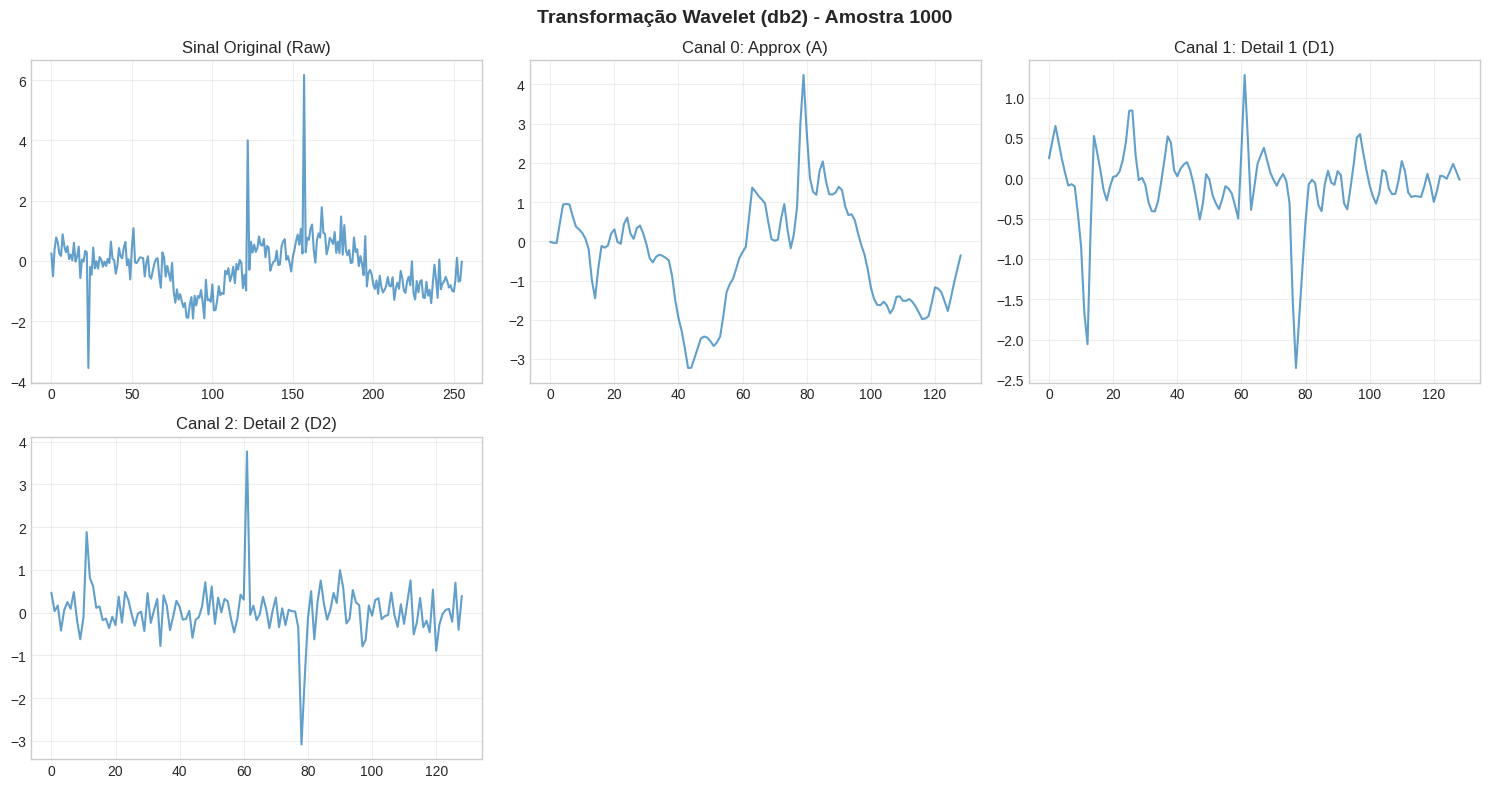

In [4]:
# Visualizar uma amostra transformada
sample_idx = 1000
n_channels = X_train.shape[2]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Sinal original
axes[0, 0].plot(X_train_raw[sample_idx], alpha=0.7)
axes[0, 0].set_title('Sinal Original (Raw)')
axes[0, 0].grid(True, alpha=0.3)

# Coeficientes wavelet - ajustar nomes ao número real de canais
all_channel_names = ['Approx (A)', 'Detail 1 (D1)', 'Detail 2 (D2)', 
                     'Detail 3 (D3)', 'Detail 4 (D4)']
channel_names = all_channel_names[:n_channels]
for i, (ax, name) in enumerate(zip(axes.flatten()[1:n_channels+1], channel_names)):
    ax.plot(X_train[sample_idx, :, i], alpha=0.7)
    ax.set_title(f'Canal {i}: {name}')
    ax.grid(True, alpha=0.3)

# Esconder subplots não usados
for ax in axes.flatten()[n_channels+1:]:
    ax.set_visible(False)

plt.suptitle(f'Transformação Wavelet (db2) - Amostra {sample_idx}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dl_wavelet_experiments" / "wavelet_transformation_sample.png", dpi=150)
plt.show()

## 3. Configuração

In [5]:
# Gerenciadores
results_manager = ResultsManager(RESULTS_DIR / "dl_wavelet_experiments")
evaluator = RegressionEvaluator()
visualizer = ExperimentVisualizer()

training_config = DL_TRAINING_CONFIG.copy()

# Armazenar resultados
all_results = {}          # melhor de cada arquitetura
all_histories = {}        # histórico do melhor
all_grid_results = []     # TODOS os resultados do grid

## 4. Experimento 1: CNN + Wavelet

In [6]:
print("="*70)
print("🔵 Grid Search: CNN com Wavelet db2")
print("="*70)

grid = generate_dl_grid('CNN')
base_params = DL_MODELS_CONFIG['CNN'].copy()
best_rmse, best_key = float('inf'), None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Wavelet_CNN_g{gi}"

    _done = {e['model_name'] for e in results_manager.experiments_log}
    if run_name in _done:
        _ex = next(e for e in results_manager.experiments_log if e['model_name'] == run_name)
        _m = _ex['metrics']
        print(f"    [SKIP] {run_name} — já concluído (RMSE={_m['rmse']:.6f})")
        row = {'Model': 'Wavelet_CNN', 'grid_idx': gi, **variation,
               'RMSE': _m['rmse'], 'MAE': _m['mae'], 'R²': _m['r2'],
               'Params': 0, 'Time (s)': 0, 'Epochs': 0}
        all_grid_results.append(row)
        if _m['rmse'] < best_rmse:
            best_rmse = _m['rmse']
            best_key = run_name
            all_results['Wavelet_CNN'] = {'metrics': _m, 'time': 0, 'epochs': 0,
                'y_pred': np.zeros(len(y_test)), 'params': 0, 'best_variation': variation}
        continue
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_cnn_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"wavelet_cnn_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config['early_stopping_patience'],
        patience_lr=training_config['reduce_lr_patience'],
        min_lr=training_config['min_lr'],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config['epochs'],
        batch_size=training_config['batch_size'],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_pred = model.predict(X_test, verbose=0).flatten()
    metrics = evaluator.evaluate(y_test, y_pred)

    print(f"    RMSE={metrics['rmse']:.6f}  MAE={metrics['mae']:.6f}  "
          f"R²={metrics['r2']:.6f}  Time={elapsed:.1f}s")

    row = {'Model': 'Wavelet_CNN', 'grid_idx': gi, **variation,
           'RMSE': metrics['rmse'], 'MAE': metrics['mae'],
           'R²': metrics['r2'], 'Params': model.count_params(),
           'Time (s)': elapsed, 'Epochs': len(history.history['loss'])}
    all_grid_results.append(row)

    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_key = run_name
        all_results['Wavelet_CNN'] = {
            'metrics': metrics, 'time': elapsed,
            'epochs': len(history.history['loss']),
            'y_pred': y_pred, 'params': model.count_params(),
            'best_variation': variation,
        }
        all_histories['Wavelet_CNN'] = history.history
        model.save(str(MODELS_DIR / "wavelet_cnn_best.keras"))

    results_manager.log_experiment('DL_Wavelet', run_name, metrics,
                                   {'params': params, 'wavelet': WAVELET_CONFIG})

print(f"\n🏆 Melhor CNN: {best_key} — RMSE={best_rmse:.6f}")

🔵 Grid Search: CNN com Wavelet db2
    [SKIP] Wavelet_CNN_g0 — já concluído (RMSE=0.254052)
    [SKIP] Wavelet_CNN_g1 — já concluído (RMSE=0.243044)
    [SKIP] Wavelet_CNN_g2 — já concluído (RMSE=0.259418)
    [SKIP] Wavelet_CNN_g3 — já concluído (RMSE=0.255378)
    [SKIP] Wavelet_CNN_g4 — já concluído (RMSE=0.239657)
    [SKIP] Wavelet_CNN_g5 — já concluído (RMSE=0.232004)
    [SKIP] Wavelet_CNN_g6 — já concluído (RMSE=0.235077)
    [SKIP] Wavelet_CNN_g7 — já concluído (RMSE=0.248694)
    [SKIP] Wavelet_CNN_g8 — já concluído (RMSE=0.238608)
    [SKIP] Wavelet_CNN_g9 — já concluído (RMSE=0.224470)
    [SKIP] Wavelet_CNN_g10 — já concluído (RMSE=0.241987)
    [SKIP] Wavelet_CNN_g11 — já concluído (RMSE=0.233275)
    [SKIP] Wavelet_CNN_g12 — já concluído (RMSE=0.235952)
    [SKIP] Wavelet_CNN_g13 — já concluído (RMSE=0.249114)
    [SKIP] Wavelet_CNN_g14 — já concluído (RMSE=0.247900)
    [SKIP] Wavelet_CNN_g15 — já concluído (RMSE=0.246075)
    [SKIP] Wavelet_CNN_g16 — já concluído (RMSE

## 5. Experimento 2: LSTM + Wavelet

In [7]:
print("="*70)
print("🔵 Grid Search: LSTM com Wavelet db2")
print("="*70)

grid = generate_dl_grid('LSTM')
base_params = DL_MODELS_CONFIG['LSTM'].copy()
best_rmse, best_key = float('inf'), None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Wavelet_LSTM_g{gi}"

    _done = {e['model_name'] for e in results_manager.experiments_log}
    if run_name in _done:
        _ex = next(e for e in results_manager.experiments_log if e['model_name'] == run_name)
        _m = _ex['metrics']
        print(f"    [SKIP] {run_name} — já concluído (RMSE={_m['rmse']:.6f})")
        row = {'Model': 'Wavelet_LSTM', 'grid_idx': gi, **variation,
               'RMSE': _m['rmse'], 'MAE': _m['mae'], 'R²': _m['r2'],
               'Params': 0, 'Time (s)': 0, 'Epochs': 0}
        all_grid_results.append(row)
        if _m['rmse'] < best_rmse:
            best_rmse = _m['rmse']
            best_key = run_name
            all_results['Wavelet_LSTM'] = {'metrics': _m, 'time': 0, 'epochs': 0,
                'y_pred': np.zeros(len(y_test)), 'params': 0, 'best_variation': variation}
        continue
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_lstm_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"wavelet_lstm_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config['early_stopping_patience'],
        patience_lr=training_config['reduce_lr_patience'],
        min_lr=training_config['min_lr'],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config['epochs'],
        batch_size=training_config['batch_size'],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_pred = model.predict(X_test, verbose=0).flatten()
    metrics = evaluator.evaluate(y_test, y_pred)

    print(f"    RMSE={metrics['rmse']:.6f}  MAE={metrics['mae']:.6f}  "
          f"R²={metrics['r2']:.6f}  Time={elapsed:.1f}s")

    row = {'Model': 'Wavelet_LSTM', 'grid_idx': gi, **variation,
           'RMSE': metrics['rmse'], 'MAE': metrics['mae'],
           'R²': metrics['r2'], 'Params': model.count_params(),
           'Time (s)': elapsed, 'Epochs': len(history.history['loss'])}
    all_grid_results.append(row)

    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_key = run_name
        all_results['Wavelet_LSTM'] = {
            'metrics': metrics, 'time': elapsed,
            'epochs': len(history.history['loss']),
            'y_pred': y_pred, 'params': model.count_params(),
            'best_variation': variation,
        }
        all_histories['Wavelet_LSTM'] = history.history
        model.save(str(MODELS_DIR / "wavelet_lstm_best.keras"))

    results_manager.log_experiment('DL_Wavelet', run_name, metrics,
                                   {'params': params, 'wavelet': WAVELET_CONFIG})

print(f"\n🏆 Melhor LSTM: {best_key} — RMSE={best_rmse:.6f}")

🔵 Grid Search: LSTM com Wavelet db2
    [SKIP] Wavelet_LSTM_g0 — já concluído (RMSE=0.298952)
    [SKIP] Wavelet_LSTM_g1 — já concluído (RMSE=0.291461)
    [SKIP] Wavelet_LSTM_g2 — já concluído (RMSE=0.277979)
    [SKIP] Wavelet_LSTM_g3 — já concluído (RMSE=0.294117)
    [SKIP] Wavelet_LSTM_g4 — já concluído (RMSE=0.318702)
    [SKIP] Wavelet_LSTM_g5 — já concluído (RMSE=0.321023)
    [SKIP] Wavelet_LSTM_g6 — já concluído (RMSE=0.327440)
    [SKIP] Wavelet_LSTM_g7 — já concluído (RMSE=0.344472)
    [SKIP] Wavelet_LSTM_g8 — já concluído (RMSE=0.330320)
    [SKIP] Wavelet_LSTM_g9 — já concluído (RMSE=0.335086)
    [SKIP] Wavelet_LSTM_g10 — já concluído (RMSE=0.321403)
    [SKIP] Wavelet_LSTM_g11 — já concluído (RMSE=0.342811)
    [SKIP] Wavelet_LSTM_g12 — já concluído (RMSE=0.425515)
    [SKIP] Wavelet_LSTM_g13 — já concluído (RMSE=0.411150)
    [SKIP] Wavelet_LSTM_g14 — já concluído (RMSE=0.391887)
    [SKIP] Wavelet_LSTM_g15 — já concluído (RMSE=0.400371)
    [SKIP] Wavelet_LSTM_g16 — 

## 6. Experimento 3: CNN-LSTM + Wavelet

In [8]:
print("="*70)
print("🔵 Grid Search: CNN-LSTM com Wavelet db2")
print("="*70)

grid = generate_dl_grid('CNN_LSTM')
base_params = DL_MODELS_CONFIG['CNN_LSTM'].copy()
best_rmse, best_key = float('inf'), None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Wavelet_CNN_LSTM_g{gi}"

    _done = {e['model_name'] for e in results_manager.experiments_log}
    if run_name in _done:
        _ex = next(e for e in results_manager.experiments_log if e['model_name'] == run_name)
        _m = _ex['metrics']
        print(f"    [SKIP] {run_name} — já concluído (RMSE={_m['rmse']:.6f})")
        row = {'Model': 'Wavelet_CNN_LSTM', 'grid_idx': gi, **variation,
               'RMSE': _m['rmse'], 'MAE': _m['mae'], 'R²': _m['r2'],
               'Params': 0, 'Time (s)': 0, 'Epochs': 0}
        all_grid_results.append(row)
        if _m['rmse'] < best_rmse:
            best_rmse = _m['rmse']
            best_key = run_name
            all_results['Wavelet_CNN_LSTM'] = {'metrics': _m, 'time': 0, 'epochs': 0,
                'y_pred': np.zeros(len(y_test)), 'params': 0, 'best_variation': variation}
        continue
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_cnn_lstm_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"wavelet_cnn_lstm_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config['early_stopping_patience'],
        patience_lr=training_config['reduce_lr_patience'],
        min_lr=training_config['min_lr'],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config['epochs'],
        batch_size=training_config['batch_size'],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_pred = model.predict(X_test, verbose=0).flatten()
    metrics = evaluator.evaluate(y_test, y_pred)

    print(f"    RMSE={metrics['rmse']:.6f}  MAE={metrics['mae']:.6f}  "
          f"R²={metrics['r2']:.6f}  Time={elapsed:.1f}s")

    row = {'Model': 'Wavelet_CNN_LSTM', 'grid_idx': gi, **variation,
           'RMSE': metrics['rmse'], 'MAE': metrics['mae'],
           'R²': metrics['r2'], 'Params': model.count_params(),
           'Time (s)': elapsed, 'Epochs': len(history.history['loss'])}
    all_grid_results.append(row)

    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_key = run_name
        all_results['Wavelet_CNN_LSTM'] = {
            'metrics': metrics, 'time': elapsed,
            'epochs': len(history.history['loss']),
            'y_pred': y_pred, 'params': model.count_params(),
            'best_variation': variation,
        }
        all_histories['Wavelet_CNN_LSTM'] = history.history
        model.save(str(MODELS_DIR / "wavelet_cnn_lstm_best.keras"))

    results_manager.log_experiment('DL_Wavelet', run_name, metrics,
                                   {'params': params, 'wavelet': WAVELET_CONFIG})

print(f"\n🏆 Melhor CNN-LSTM: {best_key} — RMSE={best_rmse:.6f}")

🔵 Grid Search: CNN-LSTM com Wavelet db2
    [SKIP] Wavelet_CNN_LSTM_g0 — já concluído (RMSE=0.257085)
    [SKIP] Wavelet_CNN_LSTM_g1 — já concluído (RMSE=0.247396)
    [SKIP] Wavelet_CNN_LSTM_g2 — já concluído (RMSE=0.249958)
    [SKIP] Wavelet_CNN_LSTM_g3 — já concluído (RMSE=0.249034)
    [SKIP] Wavelet_CNN_LSTM_g4 — já concluído (RMSE=0.270421)
    [SKIP] Wavelet_CNN_LSTM_g5 — já concluído (RMSE=0.286458)
    [SKIP] Wavelet_CNN_LSTM_g6 — já concluído (RMSE=0.252113)
    [SKIP] Wavelet_CNN_LSTM_g7 — já concluído (RMSE=0.263589)
    [SKIP] Wavelet_CNN_LSTM_g8 — já concluído (RMSE=0.277082)
    [SKIP] Wavelet_CNN_LSTM_g9 — já concluído (RMSE=0.277516)
    [SKIP] Wavelet_CNN_LSTM_g10 — já concluído (RMSE=0.258527)
    [SKIP] Wavelet_CNN_LSTM_g11 — já concluído (RMSE=0.278704)
    [SKIP] Wavelet_CNN_LSTM_g12 — já concluído (RMSE=0.270820)
    [SKIP] Wavelet_CNN_LSTM_g13 — já concluído (RMSE=0.276140)
    [SKIP] Wavelet_CNN_LSTM_g14 — já concluído (RMSE=0.259615)
    [SKIP] Wavelet_CNN_LS

## 7. Experimento 4: Transformer + Wavelet

In [9]:
print("="*70)
print("🔵 Grid Search: Transformer com Wavelet db2")
print("="*70)

grid = generate_dl_grid('Transformer')
base_params = DL_MODELS_CONFIG['Transformer'].copy()
best_rmse, best_key = float('inf'), None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"Wavelet_Transformer_g{gi}"

    _done = {e['model_name'] for e in results_manager.experiments_log}
    if run_name in _done:
        _ex = next(e for e in results_manager.experiments_log if e['model_name'] == run_name)
        _m = _ex['metrics']
        print(f"    [SKIP] {run_name} — já concluído (RMSE={_m['rmse']:.6f})")
        row = {'Model': 'Wavelet_Transformer', 'grid_idx': gi, **variation,
               'RMSE': _m['rmse'], 'MAE': _m['mae'], 'R²': _m['r2'],
               'Params': 0, 'Time (s)': 0, 'Epochs': 0}
        all_grid_results.append(row)
        if _m['rmse'] < best_rmse:
            best_rmse = _m['rmse']
            best_key = run_name
            all_results['Wavelet_Transformer'] = {'metrics': _m, 'time': 0, 'epochs': 0,
                'y_pred': np.zeros(len(y_test)), 'params': 0, 'best_variation': variation}
        continue
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_transformer_model(input_shape, params=params)

    model_path = str(MODELS_DIR / f"wavelet_transformer_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config['early_stopping_patience'],
        patience_lr=training_config['reduce_lr_patience'],
        min_lr=training_config['min_lr'],
        use_reduce_lr=not params.get('use_warmup', True),
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config['epochs'],
        batch_size=training_config['batch_size'],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_pred = model.predict(X_test, verbose=0).flatten()
    metrics = evaluator.evaluate(y_test, y_pred)

    print(f"    RMSE={metrics['rmse']:.6f}  MAE={metrics['mae']:.6f}  "
          f"R²={metrics['r2']:.6f}  Time={elapsed:.1f}s")

    row = {'Model': 'Wavelet_Transformer', 'grid_idx': gi, **variation,
           'RMSE': metrics['rmse'], 'MAE': metrics['mae'],
           'R²': metrics['r2'], 'Params': model.count_params(),
           'Time (s)': elapsed, 'Epochs': len(history.history['loss'])}
    all_grid_results.append(row)

    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_key = run_name
        all_results['Wavelet_Transformer'] = {
            'metrics': metrics, 'time': elapsed,
            'epochs': len(history.history['loss']),
            'y_pred': y_pred, 'params': model.count_params(),
            'best_variation': variation,
        }
        all_histories['Wavelet_Transformer'] = history.history
        model.save(str(MODELS_DIR / "wavelet_transformer_best.keras"))

    results_manager.log_experiment('DL_Wavelet', run_name, metrics,
                                   {'params': params, 'wavelet': WAVELET_CONFIG})

print(f"\n🏆 Melhor Transformer: {best_key} — RMSE={best_rmse:.6f}")

🔵 Grid Search: Transformer com Wavelet db2
    [SKIP] Wavelet_Transformer_g0 — já concluído (RMSE=0.202145)
    [SKIP] Wavelet_Transformer_g1 — já concluído (RMSE=0.209828)
    [SKIP] Wavelet_Transformer_g2 — já concluído (RMSE=0.199080)
    [SKIP] Wavelet_Transformer_g3 — já concluído (RMSE=0.210143)

--- [5/48] Wavelet_Transformer_g4: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 128, 'num_transformer_blocks': 2, 'l2_reg': 0.0001}


I0000 00:00:1777315549.239280   67593 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


Epoch 44: early stopping


Restoring model weights from the end of the best epoch: 29.


    RMSE=0.220492  MAE=0.170855  R²=0.951892  Time=372.6s

--- [6/48] Wavelet_Transformer_g5: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 128, 'num_transformer_blocks': 2, 'l2_reg': 0.001}


...

    RMSE=0.225945  MAE=0.174960  R²=0.949483  Time=444.7s

--- [7/48] Wavelet_Transformer_g6: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 128, 'num_transformer_blocks': 3, 'l2_reg': 0.0001}


Epoch 39: early stopping


Restoring model weights from the end of the best epoch: 24.


    RMSE=0.198092  MAE=0.152099  R²=0.961170  Time=438.6s

--- [8/48] Wavelet_Transformer_g7: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 128, 'num_transformer_blocks': 3, 'l2_reg': 0.001}


Epoch 34: early stopping


## 8. Comparação dos Resultados

In [ ]:
# Criar DataFrame comparativo (melhor de cada arquitetura)
comparison_data = []
for model_name, result in all_results.items():
    row = {
        'Model': model_name,
        'RMSE': result['metrics']['rmse'],
        'MAE': result['metrics']['mae'],
        'R²': result['metrics']['r2'],
        'Params': result['params'],
        'Time (s)': result['time'],
        'Epochs': result['epochs']
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('RMSE')

print("\n" + "="*70)
print("📊 COMPARAÇÃO FINAL - Deep Learning com Wavelet db2 (melhor por arquitetura)")
print("="*70)
print(comparison_df.to_string(index=False))

# Salvar comparação (melhor por modelo)
out_dir = RESULTS_DIR / "dl_wavelet_experiments"
comparison_df.to_csv(out_dir / "comparison_dl_wavelet.csv", index=False)

# Salvar TODOS os resultados do grid
grid_df = pd.DataFrame(all_grid_results)
grid_df.to_csv(out_dir / "all_grid_results_dl_wavelet.csv", index=False)
print(f"\n✅ CSV comparação salvo: {out_dir / 'comparison_dl_wavelet.csv'}")
print(f"✅ CSV grid completo salvo: {out_dir / 'all_grid_results_dl_wavelet.csv'}")
print(f"   Total de combinações treinadas: {len(grid_df)}")

In [ ]:
# Visualização comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['RMSE', 'MAE', 'R²']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(comparison_df)))

for idx, metric in enumerate(metrics_to_plot):
    data = comparison_df.set_index('Model')[metric].sort_values(
        ascending=(metric != 'R²')
    )
    bars = axes[idx].barh(data.index, data.values, color=colors)
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(f'Comparação: {metric}')
    axes[idx].grid(True, alpha=0.3, axis='x')
    
    for bar, val in zip(bars, data.values):
        axes[idx].text(val, bar.get_y() + bar.get_height()/2,
                      f'{val:.4f}', va='center', ha='left', fontsize=9)

plt.suptitle('Deep Learning com Wavelet db2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dl_wavelet_experiments" / "comparison_dl_wavelet.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Evolução do Treinamento

Visualização detalhada da evolução do processo de treinamento para cada arquitetura com wavelet db2:
- **Loss** (Train vs Validation) ao longo das épocas
- **Convergência** — velocidade e estabilidade
- **Early Stopping** — ponto de parada otimizado

In [ ]:
# ── Evolução do Treinamento: Loss (Train vs Val) por modelo ──
n_models = len(all_histories)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors_lines = {'loss': '#2196F3', 'val_loss': '#F44336'}

for idx, (model_name, history) in enumerate(all_histories.items()):
    ax = axes[idx]
    epochs_range = range(1, len(history['loss']) + 1)
    
    # Train & Val loss
    ax.plot(epochs_range, history['loss'], color=colors_lines['loss'],
            linewidth=2, label='Train Loss', alpha=0.9)
    ax.plot(epochs_range, history['val_loss'], color=colors_lines['val_loss'],
            linewidth=2, label='Val Loss', alpha=0.9)
    
    # Marcar melhor época (menor val_loss)
    best_epoch = np.argmin(history['val_loss']) + 1
    best_val = min(history['val_loss'])
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch={best_epoch}')
    ax.scatter([best_epoch], [best_val], color='green', s=100, zorder=5, edgecolors='black')
    
    # Anotação
    ax.annotate(f'Val Loss={best_val:.6f}',
                xy=(best_epoch, best_val),
                xytext=(best_epoch + len(epochs_range)*0.05, best_val * 1.15),
                fontsize=9, color='green',
                arrowprops=dict(arrowstyle='->', color='green', alpha=0.7))
    
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('Loss (MSE)', fontsize=11)
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

# Esconder subplots não usados
for idx in range(n_models, 4):
    axes[idx].set_visible(False)

plt.suptitle('Evolução do Treinamento — DL Wavelet db2 (Loss por Época)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dl_wavelet_experiments" / "training_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Comparativo: todas as curvas de val_loss sobrepostas ──
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.tab10
for idx, (model_name, history) in enumerate(all_histories.items()):
    epochs_range = range(1, len(history['val_loss']) + 1)
    ax.plot(epochs_range, history['val_loss'], linewidth=2, label=model_name,
            color=cmap(idx), alpha=0.85)
    best_ep = np.argmin(history['val_loss']) + 1
    best_vl = min(history['val_loss'])
    ax.scatter([best_ep], [best_vl], color=cmap(idx), s=80, zorder=5, edgecolors='black')

ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Validation Loss (MSE)', fontsize=12)
ax.set_title('Comparativo — Convergência Val Loss (DL Wavelet db2)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dl_wavelet_experiments" / "val_loss_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Resumo numérico da evolução ──
print("\n📊 Resumo da Evolução do Treinamento:")
print(f"{'Modelo':<25} {'Épocas':>7} {'Train Loss Final':>16} {'Val Loss Final':>15} {'Best Val Loss':>14} {'Best Epoch':>11}")
print("-" * 95)
for model_name, history in all_histories.items():
    n_ep = len(history['loss'])
    best_ep = np.argmin(history['val_loss']) + 1
    print(f"{model_name:<25} {n_ep:>7} {history['loss'][-1]:>16.6f} {history['val_loss'][-1]:>15.6f} {min(history['val_loss']):>14.6f} {best_ep:>11}")

## 10. Resumo

In [ ]:
# Encontrar melhor modelo
best_model_name = comparison_df.iloc[0]['Model']

print("\n" + "="*70)
print("📋 RESUMO - Experimentos DL com Wavelet db2")
print("="*70)
print(f"\n✅ Modelos avaliados: {len(all_results)}")
print(f"✅ Melhor modelo: {best_model_name}")
print(f"✅ Melhor RMSE: {comparison_df.iloc[0]['RMSE']:.6f}")
print(f"✅ Melhor R²: {comparison_df.iloc[0]['R²']:.6f}")
print(f"\n📁 Resultados salvos em: {RESULTS_DIR / 'dl_wavelet_experiments'}")
print("\n🎉 Notebook concluído com sucesso!")